## Limpiar cocheras que debieron caer

In [64]:
from pathlib import Path
import pandas as pd
import numpy as np
import json
import datetime as dt
import re
from difflib import get_close_matches

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)
print('Importadas ok')
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

Importadas ok


### BD

In [65]:
carpeta = "../data/raw/"
procesos_file = carpeta + "procesos.parquet"
unidades_file = carpeta + "unidades.parquet"
df_procesos = pd.read_parquet(procesos_file)
df_unidades = pd.read_parquet(unidades_file)

df_procesos.head(2)

,codigo_proyecto,nombre_proyecto,tipo_unidad_principal,codigo_unidad,total_unidades,codigo_unidades_asignadas,nombres_cliente,apellidos_cliente,documento_cliente,origen_proforma,fecha_proforma,codigo_proforma,numero_contrato,fecha_contrato,modalidad_contrato,moneda,tipo_cambio,tipo_financiamiento,banco,situacion_legal,documento_representante,nombres_usuario,username,precio_base_proforma,descuento_venta,precio_venta,aprobador_descuento,nombre,premios,fecha_inicio,fecha_fin,fecha_expiracion,fecha_impresion_contrato,nombre_flujo,estado,completado,total_pagado,total_pendiente,fecha_analisis,fecha_nif,estado_nif,utm_source,utm_medium,utm_campaign,utm_term,utm_content,documento_conyuge,documento_copropietarios,flujo_anulacion,fecha_anulacion,codigo_externo_venta,id,tipo,fecha_actualizacion,codigo_externo_minuta,flujo_error,momento_caida,tipo_cronograma,estado_contrato,devolucion,fecha_devolucion,excedente,observacion_devolucion,motivo_caida,nombres_usuario_aprobador,username_aprobador,cliente_id,usuario_creador,username_creador,usuario_separacion,codigo_externo_entrega,fecha_minuta,proforma_id,penalidad,proceso_anulacion,codigo_externo_anulacion_venta,terminado,paso_actual,estado_personalizado
0,EEUU,Edificio Urbanzen,departamento flat,EEUU-302,2,EEUU-E19,Jan Henri,Larsen,48997555,manual,2025-09-16,2025-05785,NaN,None,Compromiso,PEN,1.000000,hipotecario,NaN,Conyugal,17896123,Yomira Pacheco,ypacheco,712460.00,77460.00,635000.00,ldelsolar,Entrega,None,2026-01-26,2026-01-30,None,None,Proceso de entrega,Activo,Completado,0.00,0.00,2026-01-30,None,NaN,None,None,None,None,None,17896123,NaN,NaN,None,None,21,ENTREGA,2026-01-30,None,False,NaN,NaN,NaN,0.00,None,0.0,NaN,None,NaN,NaN,121739,JOSUE QUIROGA NAVARRO,jquiroga,NaN,None,None,26094,0.00,al iniciar,None,None,Proceso Terminado,None
1,EEUU,Edificio Urbanzen,departamento flat,EEUU-1501,2,EEUU-E26,Katherine Jessy,Bendezú Delgadillo,45347923,manual,2024-03-19,2024-00497,NaN,None,Compromiso,PEN,1.000000,ahorro,Banco de Crédito del Perú (BCP),Propietario Solo,NaN,Nelly Román Villavicencio,nroman,659509.20,72744.51,586764.69,evillanueva,Entrega,None,2026-03-17,2026-03-17,None,None,Proceso de entrega,Activo,Completado,0.00,0.00,2026-03-17,None,NaN,None,None,None,None,None,NaN,NaN,NaN,None,None,68,ENTREGA,2026-03-17,None,False,NaN,NaN,NaN,0.00,None,0.0,NaN,None,NaN,NaN,43624,JOSUE QUIROGA NAVARRO,jquiroga,NaN,None,None,16905,0.00,al iniciar,None,None,Proceso Terminado,None


In [66]:
#df_procesos.info()
#df_procesos['tipo_unidad_principal'].value_counts()

# Helpers

### Filtrar df = por columnas con diccionario

In [67]:
import pandas as pd


def filtrar_df(df, condiciones, mostrar_resumen=True):
    cantidad_antes = len(df)

    mascara = pd.Series(True, index=df.index)

    for columna, condicion in condiciones.items():

        if columna not in df.columns:
            raise KeyError(
                f"La columna '{columna}' no existe en el DataFrame."
            )

        serie = df[columna]

        # Nulos, textos vacíos o textos compuestos solo por espacios
        es_vacio = (
            serie.isna()
            | serie.astype("string")
                   .str.strip()
                   .eq("")
                   .fillna(False)
        )

        # Condiciones con operadores
        if isinstance(condicion, dict):

            operador = condicion.get("op")

            if operador == "vacio":
                mascara &= es_vacio

            elif operador == "no_vacio":
                mascara &= ~es_vacio

            elif operador == "igual":
                valor = condicion.get("valor")
                mascara &= serie.eq(valor)

            elif operador == "en":
                valores = condicion.get("valores", [])
                mascara &= serie.isin(valores)

            else:
                raise ValueError(
                    f"Operador '{operador}' no reconocido "
                    f"para la columna '{columna}'."
                )

        # Si recibe una lista, actúa como IN
        elif isinstance(condicion, (list, tuple, set)):
            mascara &= serie.isin(condicion)

        # Si recibe un valor normal, actúa como igualdad
        else:
            mascara &= serie.eq(condicion)

    resultado = df.loc[mascara].copy()

    cantidad_despues = len(resultado)
    cantidad_eliminada = cantidad_antes - cantidad_despues

    porcentaje_conservado = (
        cantidad_despues / cantidad_antes * 100
        if cantidad_antes > 0
        else 0
    )

    if mostrar_resumen:
        print("Resumen del filtro")
        print(f"Filas antes:       {cantidad_antes:,}")
        print(f"Filas después:     {cantidad_despues:,}")
        print(f"Filas descartadas: {cantidad_eliminada:,}")
        print(f"Porcentaje conservado: {porcentaje_conservado:.2f}%")

    return resultado

# PROCESAR

### 1) Filtrar solo proyectos relevantes

Resumen del filtro
Filas antes:       4,830
Filas después:     2,733
Filas descartadas: 2,097
Porcentaje conservado: 56.58%

codigo_proyecto
TZ      462
NP      325
EEUU    275
MD      275
MA      259
SL      258
GY      254
FX      238
MT      208
CP      179
Name: count, dtype: int64


<Axes: title={'center': 'Cantidad de procesos por proyecto'}, ylabel='nombre_proyecto'>

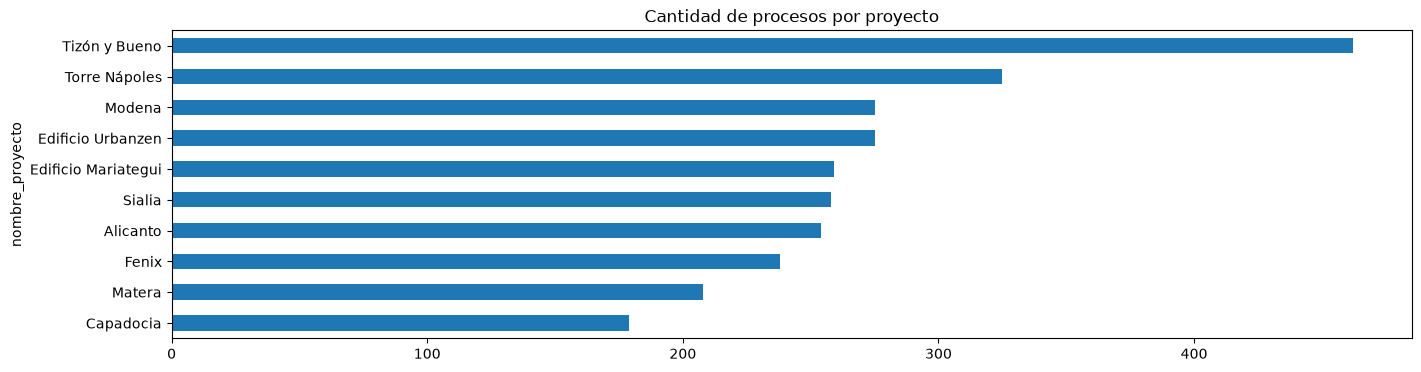

In [68]:
condiciones = {
                'estado': 'Activo',
                "codigo_proyecto": ["TZ", "NP", "EEUU", "MD", "MA", "SL", "GY", "FX", "MT", "CP"],
                #'codigo_unidad': 'TZ-1301'
                #"codigo_unidades_asignadas": {"op": "vacio"}
}

df_procesos = filtrar_df(df_procesos, condiciones)
print()
print(df_procesos['codigo_proyecto'].value_counts())
#df_procesos.sample(7)
#df_procesos['codigo_proyecto'].value_counts().plot(figsize=(16, 4))
df_procesos['nombre_proyecto'].value_counts().sort_values().plot(
    kind='barh',
    figsize=(16, 4),
    title='Cantidad de procesos por proyecto'
)

### 2) Homologar unidades

Procesos Totales: 2733
tipo_unidad_principal         tipo_unidad_homologado  estado
departamento flat             departamento            Activo    2319
estacionamiento simple        estacionamiento         Activo     202
estacionamiento con depósito  estacionamiento         Activo     133
departamento duplex           departamento            Activo      41
depósito                      deposito                Activo      35
local comercial               local comercial         Activo       3
Name: count, dtype: int64


<Axes: title={'center': 'Unidades de proyectos activos'}, ylabel='tipo_unidad_homologado'>

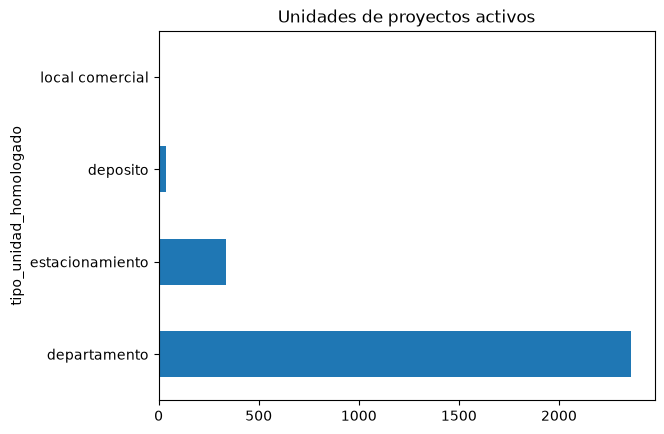

In [75]:
print(f'Procesos Totales: {df_procesos.shape[0]}')

def añadir_unidad_general(tipo):
    if tipo.startswith('departamento'):
        x= 'departamento'
    elif tipo.startswith('estacionamiento'):
        x= 'estacionamiento'
    elif tipo.startswith('depósito'):
        x= 'deposito'
    elif tipo.startswith('local comercial'):
        x= 'local comercial'
    else:
        x='otro'

    return x

df_procesos['tipo_unidad_homologado'] = df_procesos['tipo_unidad_principal'].apply(añadir_unidad_general)

print(df_procesos[['tipo_unidad_principal', 'tipo_unidad_homologado' ,'estado']].value_counts())

df_procesos['tipo_unidad_homologado'].value_counts().plot(kind='barh', title = 'Unidades de proyectos activos')

### 3) Solo Cocheras Activas y sin unidades asignadas = Universo de Riesgo

In [71]:
print(df_procesos['estado'].value_counts())

condiciones = {
                #'estado': 'Activo',
                "tipo_unidad_homologado": 'estacionamiento',
                #"celular": {"op": "no_vacio"},
                "codigo_unidades_asignadas": {"op": "vacio"}
}
df_procesos_cocheras = filtrar_df(df_procesos, condiciones)

print(df_procesos_cocheras['estado'].value_counts())
df_procesos_cocheras = filtrar_df(df_procesos, condiciones)

df_procesos_cocheras.sample(3)

estado
Activo    2733
Name: count, dtype: int64
Resumen del filtro
Filas antes:       2,733
Filas después:     317
Filas descartadas: 2,416
Porcentaje conservado: 11.60%
estado
Activo    317
Name: count, dtype: int64
Resumen del filtro
Filas antes:       2,733
Filas después:     317
Filas descartadas: 2,416
Porcentaje conservado: 11.60%


,codigo_proyecto,nombre_proyecto,tipo_unidad_principal,codigo_unidad,total_unidades,codigo_unidades_asignadas,nombres_cliente,apellidos_cliente,documento_cliente,origen_proforma,fecha_proforma,codigo_proforma,numero_contrato,fecha_contrato,modalidad_contrato,moneda,tipo_cambio,tipo_financiamiento,banco,situacion_legal,documento_representante,nombres_usuario,username,precio_base_proforma,descuento_venta,precio_venta,aprobador_descuento,nombre,premios,fecha_inicio,fecha_fin,fecha_expiracion,fecha_impresion_contrato,nombre_flujo,estado,completado,total_pagado,total_pendiente,fecha_analisis,fecha_nif,estado_nif,utm_source,utm_medium,utm_campaign,utm_term,utm_content,documento_conyuge,documento_copropietarios,flujo_anulacion,fecha_anulacion,codigo_externo_venta,id,tipo,fecha_actualizacion,codigo_externo_minuta,flujo_error,momento_caida,tipo_cronograma,estado_contrato,devolucion,fecha_devolucion,excedente,observacion_devolucion,motivo_caida,nombres_usuario_aprobador,username_aprobador,cliente_id,usuario_creador,username_creador,usuario_separacion,codigo_externo_entrega,fecha_minuta,proforma_id,penalidad,proceso_anulacion,codigo_externo_anulacion_venta,terminado,paso_actual,estado_personalizado,tipo_unidad_homologado
3657,MT,Matera,estacionamiento simple,MT-A58,1,NaN,Jessica María,Alvan Ramirez,41950248,manual,2026-01-28,2026-0001053,NaN,None,Compromiso,PEN,1.000000,crédito directo,NaN,Propietario Solo,NaN,Nelly Román Villavicencio,nroman,37925.00,0.00,37925.00,NaN,Venta,None,2026-01-29,None,2026-02-28,None,Minuta Oficial 2,Activo,No Completado,0.00,37925.00,None,None,NO NIF,None,None,None,None,None,NaN,NaN,NaN,None,None,3961,ADQUISICION,2026-01-29,None,False,NaN,Hipotecario,Pendiente,0.00,None,NaN,NaN,None,NaN,NaN,134061,Ana Lucia DelSolar,adelsolar,Nelly Román Villavicencio,None,None,30500,0.00,al iniciar,None,None,Contrato,None,estacionamiento
3876,MD,Modena,estacionamiento con depósito,MD-E48,1,NaN,Keiko Solange,Velezmoro Polo,72888230,manual,2025-11-16,2025-0008144,NaN,None,Compromiso,PEN,1.000000,crédito directo,NaN,Propietario Solo,NaN,Ana Lucia DelSolar,adelsolar,55997.00,3000.00,52997.00,ldelsolar,Separacion,None,2025-11-16,2026-01-15,2025-11-23,None,Separación de venta v2,Activo,Completado,0.00,0.00,2025-11-16,None,NO NIF,None,None,None,None,None,NaN,NaN,NaN,None,None,3626,ADQUISICION,2026-01-15,None,False,NaN,NaN,Pendiente,0.00,None,NaN,NaN,None,Diego Di Natale,ddinatale,114305,Ana Lucia DelSolar,adelsolar,Ana Lucia DelSolar,None,None,28453,0.00,al iniciar,None,None,Proceso Terminado,None,estacionamiento
1473,MT,Matera,estacionamiento con depósito,MT-A13,1,NaN,SANDRA ELIZABETH,MORALES CANAL,10294319,manual,2025-09-23,2025-05980,NaN,None,Compromiso,PEN,1.000000,hipotecario,NaN,Propietario Solo,NaN,Joceline Arizabal Corimanya,jarizabal,61894.00,0.00,61894.00,NaN,Separacion,None,2025-09-23,None,2025-09-30,None,Separación de venta v2,Activo,No Completado,0.00,0.00,2025-09-23,None,NO NIF,None,None,None,None,None,NaN,NaN,NaN,None,None,3376,ADQUISICION,2025-09-23,None,False,NaN,NaN,Pendiente,0.00,None,NaN,NaN,None,NaN,NaN,121351,Joceline Arizabal Corimanya,jarizabal,Joceline Arizabal Corimanya,None,None,26289,0.00,al iniciar,None,None,Emisión y firma de contratos de separación,None,estacionamiento


### Departamentos

In [72]:
condiciones = {
                'estado': 'Activo',
                "tipo_unidad_homologado": 'departamento'#,
                #"celular": {"op": "no_vacio"},
                #"codigo_unidades_asignadas": {"op": "vacio"}
}
df_procesos_depas = filtrar_df(df_procesos, condiciones)

print(df_procesos_depas['estado'].value_counts())
df_procesos_depas = filtrar_df(df_procesos, condiciones)

df_procesos_depas.sample(3)

Resumen del filtro
Filas antes:       2,733
Filas después:     2,360
Filas descartadas: 373
Porcentaje conservado: 86.35%
estado
Activo    2360
Name: count, dtype: int64
Resumen del filtro
Filas antes:       2,733
Filas después:     2,360
Filas descartadas: 373
Porcentaje conservado: 86.35%


,codigo_proyecto,nombre_proyecto,tipo_unidad_principal,codigo_unidad,total_unidades,codigo_unidades_asignadas,nombres_cliente,apellidos_cliente,documento_cliente,origen_proforma,fecha_proforma,codigo_proforma,numero_contrato,fecha_contrato,modalidad_contrato,moneda,tipo_cambio,tipo_financiamiento,banco,situacion_legal,documento_representante,nombres_usuario,username,precio_base_proforma,descuento_venta,precio_venta,aprobador_descuento,nombre,premios,fecha_inicio,fecha_fin,fecha_expiracion,fecha_impresion_contrato,nombre_flujo,estado,completado,total_pagado,total_pendiente,fecha_analisis,fecha_nif,estado_nif,utm_source,utm_medium,utm_campaign,utm_term,utm_content,documento_conyuge,documento_copropietarios,flujo_anulacion,fecha_anulacion,codigo_externo_venta,id,tipo,fecha_actualizacion,codigo_externo_minuta,flujo_error,momento_caida,tipo_cronograma,estado_contrato,devolucion,fecha_devolucion,excedente,observacion_devolucion,motivo_caida,nombres_usuario_aprobador,username_aprobador,cliente_id,usuario_creador,username_creador,usuario_separacion,codigo_externo_entrega,fecha_minuta,proforma_id,penalidad,proceso_anulacion,codigo_externo_anulacion_venta,terminado,paso_actual,estado_personalizado,tipo_unidad_homologado
3637,EEUU,Edificio Urbanzen,departamento flat,EEUU-1603,1,NaN,ESTEPHANIE ISABEL,ROSALES POMALAZA,74901526,manual,2024-01-24,2024-00058,NaN,None,Compromiso,PEN,1.000000,hipotecario,NaN,Propietario Solo,NaN,Joceline Arizabal Corimanya,jarizabal,648334.00,0.00,648334.00,NaN,Venta,None,2024-01-11,2024-01-11,2024-10-20,None,regularización,Activo,Completado,0.00,0.00,2024-01-11,None,NO NIF,None,None,None,None,None,NaN,NaN,NaN,None,None,1507,ADQUISICION,2025-10-29,None,False,NaN,NaN,Pendiente,0.00,None,NaN,NaN,None,Diego Di Natale,ddinatale,83716,Enzo Villanueva,evillanueva,Joceline Arizabal Corimanya,None,None,16466,0.00,al iniciar,None,None,Proceso Terminado,None,departamento
1199,MD,Modena,departamento flat,MD-2002,2,MD-E9,César Alberto,García Espinoza,16776183,manual,2025-06-28,2025-03799,NaN,None,Compromiso,PEN,1.000000,crédito directo,NaN,Propietario Solo,NaN,Antonio Martinez,amartinez,601732.74,66732.74,535000.00,amartinez,Separacion,None,2025-06-28,2025-06-28,2025-07-05,None,Separación de venta v2,Activo,Completado,0.00,0.00,2025-06-28,None,NO NIF,None,None,None,None,None,16407275,NaN,NaN,None,None,2993,ADQUISICION,2025-07-30,None,False,NaN,NaN,Pendiente,0.00,None,NaN,NaN,None,Enzo Villanueva,evillanueva,116644,Antonio Martinez,amartinez,Antonio Martinez,None,None,24108,0.00,al iniciar,None,None,Proceso Terminado,None,departamento
2163,FX,Fenix,departamento flat,FX-901,1,NaN,Lesli Vanessa,Panta Mendoza,71301364,manual,2026-03-15,2026-0002964,NaN,None,Compromiso,PEN,1.000000,hipotecario,Banco de Crédito del Perú (BCP),Propietario Solo,NaN,Luis Peñaloza,lpenaloza,549000.00,60390.00,488610.00,esoller,Anulacion,None,2026-04-14,2026-04-14,2026-05-14,None,Anulación,Activo,Completado,0.00,0.00,2026-04-14,None,NO NIF,None,None,None,None,None,NaN,NaN,Anulación,2026-04-14,None,4303,ADQUISICION,2026-04-14,None,False,proceso,NaN,Resuelto,0.00,None,NaN,NaN,None,Diego Di Natale,ddinatale,142210,Diego Di Natale,ddinatale,Luis Peñaloza,None,None,32412,0.00,al finalizar,None,None,Proceso Terminado,None,departamento
